In [3]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px

import sys; sys.path.append("..") #to direct program to the root files
from utils.get_data import get_processed_files

from datetime import datetime

In [12]:
# below are estimated date
TERRA_LUNA_CRASH_START_DATE = datetime.strptime("7 May 2022", "%d %B %Y")
GFC_CRASH_START_DATE = datetime.strptime("15 September 2008", "%d %B %Y")
PEG = 1 #For Terra Luna

# Loading needed datasets
- processed erc-20 datasets and gfc data

In [ ]:
#loading all erc_20 data
erc_20_dfs = get_processed_files("..\\datasets\\processed\\erc_20")
erc_20_dfs

{'dai_price_data':       timestamp    open  high     low   close        date  coins
 0    1648857600  0.9999   1.0  0.9989  1.0000  2022-04-02  price
 1    1648944000  1.0000   1.0  0.9989  0.9990  2022-04-03  price
 2    1649030400  0.9990   1.0  0.9989  0.9995  2022-04-04  price
 3    1649116800  0.9994   1.0  0.9987  0.9999  2022-04-05  price
 4    1649203200  0.9999   1.0  0.9988  0.9991  2022-04-06  price
 ..          ...     ...   ...     ...     ...         ...    ...
 210  1667001600  0.9997   1.0  0.9987  1.0000  2022-10-29  price
 211  1667088000  1.0000   1.0  0.9991  1.0000  2022-10-30  price
 212  1667174400  1.0000   1.0  0.9989  1.0000  2022-10-31  price
 213  1667260800  1.0000   1.0  0.9983  0.9999  2022-11-01  price
 214  1667347200  0.9999   1.0  0.9990  0.9999  2022-11-02  price
 
 [215 rows x 7 columns],
 'event_data':     Unnamed: 0                                              event   timestamp  \
 0            0  BlackRock and Fidelity Back USDC in $400 Milli... 

In [ ]:
# loading all gfc data
gfc_dfs = get_processed_files("..\\datasets\\processed\\gfc_data")
gfc_dfs

{'AIG':             Date       Close        High         Low        Open    Volume  \
 0     2005-01-03  789.595642  799.520880  788.878183  790.432726    379590   
 1     2005-01-04  792.226868  799.999660  790.552699  793.422682    379110   
 2     2005-01-05  805.380432  812.674866  796.651008  797.607644    558800   
 3     2005-01-06  806.695984  812.435949  799.999456  801.195269    408765   
 4     2005-01-07  808.130920  811.718362  804.304302  807.772191    311070   
 ...          ...         ...         ...         ...         ...       ...   
 2007  2012-12-21   26.324486   26.665474   26.021382   26.460879  31856600   
 2008  2012-12-24   26.673058   26.673058   26.172938   26.241136   6816400   
 2009  2012-12-26   26.786713   26.847335   26.491188   26.756405  11728100   
 2010  2012-12-27   26.498762   26.900372   26.066841   26.900372  16674800   
 2011  2012-12-28   26.203245   26.513925   26.142623   26.218398  11919300   
 
      ticker date_standardized  
 0       A

# Analyse public sentiment before and after Terra Luna crash

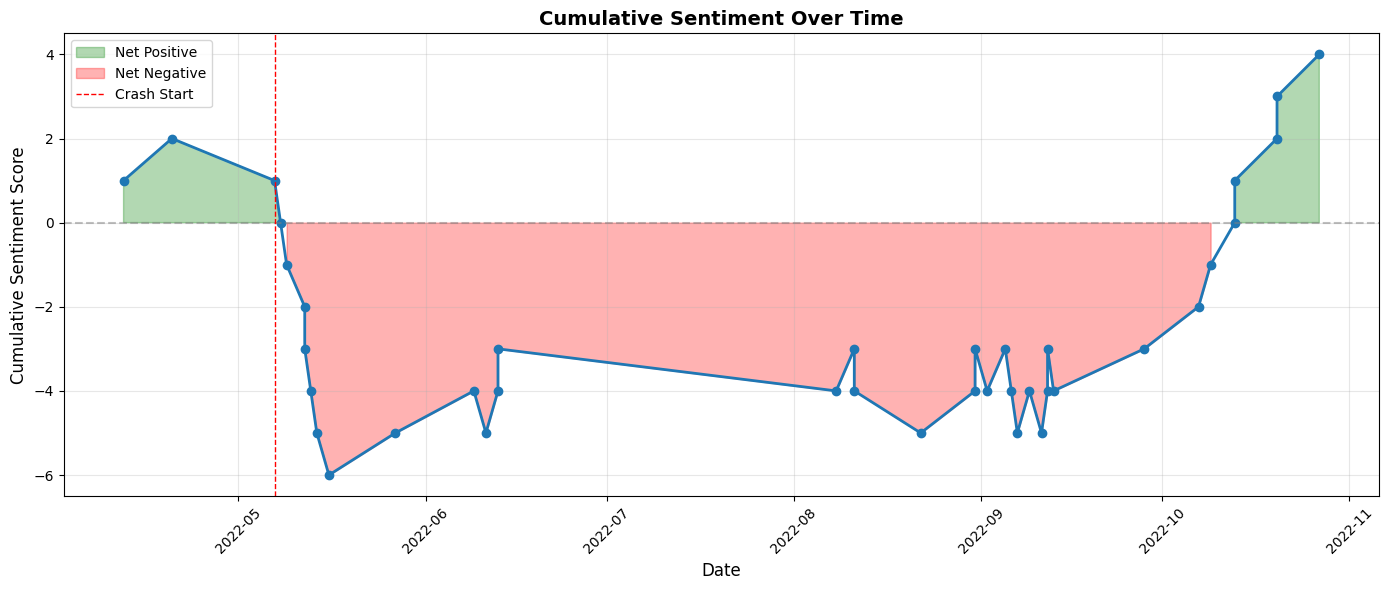

In [17]:
industry_sentiment = erc_20_dfs["event_data"] # get the df from the dictionary
industry_sentiment['date'] = pd.to_datetime(industry_sentiment['date']) #convert datetime
industry_sentiment = industry_sentiment.sort_values('date')

# Assign sentiment score
industry_sentiment['sentiment_score'] = industry_sentiment['type'].map({'positive': 1, 'negative': -1})
industry_sentiment['cumulative_sentiment'] = industry_sentiment['sentiment_score'].cumsum()

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(industry_sentiment['date'], industry_sentiment['cumulative_sentiment'], marker='o', linewidth=2, markersize=6)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.fill_between(industry_sentiment['date'], industry_sentiment['cumulative_sentiment'], 0,
                alpha=0.3, where=(industry_sentiment['cumulative_sentiment'] >= 0), color='green', label='Net Positive')
ax.fill_between(industry_sentiment['date'], industry_sentiment['cumulative_sentiment'], 0,
                alpha=0.3, where=(industry_sentiment['cumulative_sentiment'] < 0), color='red', label='Net Negative')

plt.axvline(
    x=TERRA_LUNA_CRASH_START_DATE,
    color='red',
    linestyle='--',
    linewidth=1,
    label='Crash Start'
)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Sentiment Score', fontsize=12)
ax.set_title('Cumulative Sentiment Over Time', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

We can clearly observe that following the TerraLuna crash, public sentiment declined sharply. Negative comments increased significantly and persisted from May 2022 to October 2022, after which sentiment began to gradually recover.

This indicates that public confidence started to deteriorate dramatically immediately after the crash occurred.

In [ ]:
token_transfer = erc_20_dfs["token_transfers_V3.0.0"] # get the df from the dictionary

,Unnamed: 0,block_number,transaction_index,from_address,to_address,time_stamp,contract_address,value,date
0,0,14500001,44,0x27cbb0e6885ccb1db2dab7c2314131c94795fbef,0x8426a27add8dca73548f012d92c7f8f4bbd42a3e,1648811421,0xdac17f958d2ee523a2206206994597c13d831ec7,800.000000,2022-04-01 11:10:21
1,1,14500001,62,0x7938b1b2f2d2ec6cde2db46fcb11d824f32eae54,0xffabc91efaf240a48fe2b31d3599925d3504c3df,1648811421,0xdac17f958d2ee523a2206206994597c13d831ec7,579.000000,2022-04-01 11:10:21
2,2,14500001,64,0x4593e0fb8dcc65cd24c7f99ee64da2627e90f998,0x97138e4cb36db0185236c3d74cb39fb51cb3228b,1648811421,0xdac17f958d2ee523a2206206994597c13d831ec7,15898.000000,2022-04-01 11:10:21
3,3,14500001,68,0x3cd751e6b0078be393132286c442345e5dc49699,0xf4fc2e12974cc3b4d8192722430c571968025d4f,1648811421,0xdac17f958d2ee523a2206206994597c13d831ec7,200.929675,2022-04-01 11:10:21
4,4,14500003,0,0xffec0067f5a79cff07527f63d83dd5462ccf8ba4,0x5b0e981798f5880c25b54c5de4005f5ec1f3f46a,1648811424,0xdac17f958d2ee523a2206206994597c13d831ec7,651.675449,2022-04-01 11:10:24
...,...,...,...,...,...,...,...,...,...
36723650,36723650,15872937,21,0x66e33d2605c5fb25ebb7cd7528e7997b0afa55e8,0x0eae044f00b0af300500f090ea00027097d03000,1667278439,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,10.283114,2022-11-01 04:53:59
36723651,36723651,15872937,47,0xaf0b0000f0210d0f421f0009c72406703b50506b,0xb7e99263e381fdeafe70aecd33bab743fd77597e,1667278439,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,79.504357,2022-11-01 04:53:59
36723652,36723652,15872937,62,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,0x02736d5c8dcea65539993d143a3de90cebca9c3c,1667278439,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,254.098146,2022-11-01 04:53:59
36723653,36723653,15872937,83,0x353bb62ed786cdf7624bd4049859182f3c1e9e5d,0x02f7ab8d72daf2063368e89f23fe0db9b3cb3ffd,1667278439,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,15178.209720,2022-11-01 04:53:59


# Token Transfer Analysis

# Top 10 Addresses by Transfer Volume
Group token transfers by from_address and date, then aggregate the total value transferred.

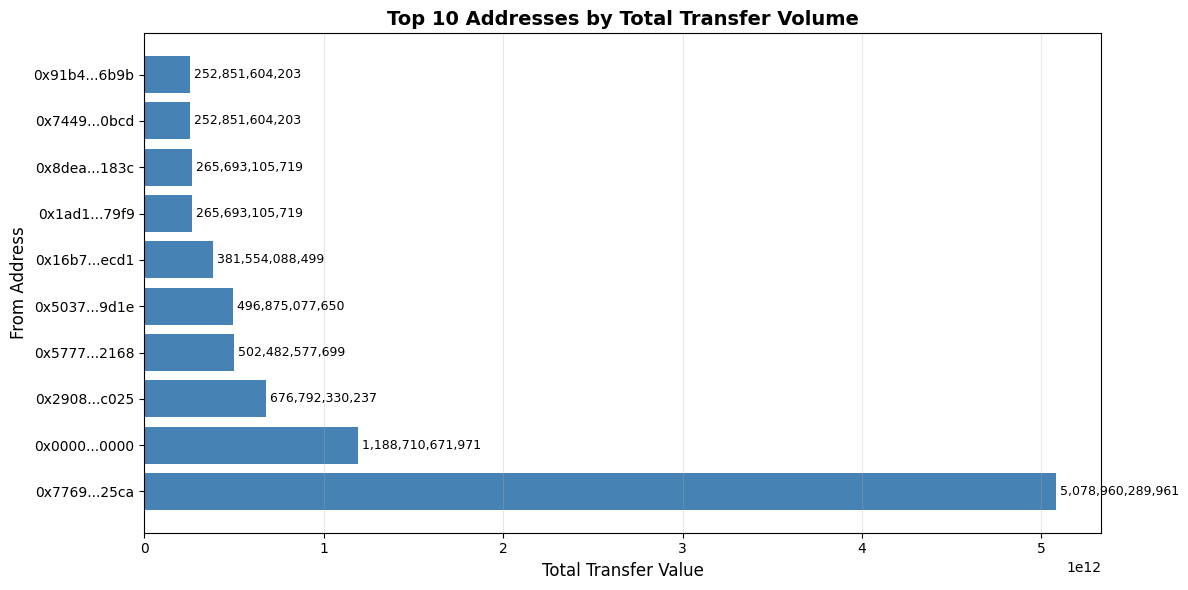


Top 10 Addresses Summary:
                              from_address        value
0x77696bb39917c91a0c3908d577d5e322095425ca 5.078960e+12
0x0000000000000000000000000000000000000000 1.188711e+12
0x29085c5e95f6ec80984b7942e192e06a0205c025 6.767923e+11
0x5777d92f208679db4b9778590fa3cab3ac9e2168 5.024826e+11
0x50379f632ca68d36e50cfbc8f78fe16bd1499d1e 4.968751e+11
0x16b70f44719b227278a2dc1122e8106cc929ecd1 3.815541e+11
0x1ad15da846de6b2251c439bb13b2b6bf9d4079f9 2.656931e+11
0x8deaaaf147e16f8584251f4b1fc1dd06c21a183c 2.656931e+11
0x74492f1c4faee6ed843a0228a08eca63e6f40bcd 2.528516e+11
0x91b4feb1935cd3bf41adfeac2306b244137c6b9b 2.528516e+11


In [ ]:
# Ensure date column is datetime
token_transfer = erc_20_dfs["token_transfers_V3.0.0"] # get the df from the dictionary
token_transfer['date'] = pd.to_datetime(token_transfer['date'])

# Group by from_address and date, sum the values
grouped_transfers = token_transfer.groupby(['from_address', 'date'])['value'].sum().reset_index()

# Get total value per address across all dates
top_10_addresses = grouped_transfers.groupby('from_address')['value'].sum().nlargest(10).reset_index()

# Plot top 10 addresses
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(len(top_10_addresses)), top_10_addresses['value'], color='steelblue')
ax.set_yticks(range(len(top_10_addresses)))
ax.set_yticklabels([f"{addr[:6]}...{addr[-4:]}" for addr in top_10_addresses['from_address']], fontsize=10)
ax.set_xlabel('Total Transfer Value', fontsize=12)
ax.set_ylabel('From Address', fontsize=12)
ax.set_title('Top 10 Addresses by Total Transfer Value', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(top_10_addresses['value']):
    ax.text(v, i, f' {v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nTop 10 Addresses Summary:")
print(top_10_addresses.to_string(index=False))

### Extracting information from erc20 data
- calculate moving average
- calculate percentage changes

In [1]:
def create_candleLit_graph(df, name, is_gfc):
    """
    Show the trend of high, open, low, close prices

    Args:
        df -> pd.DataFrame
            should consist of the following columns ("open", "high", "low", "close", "date")
        name -> String, Name of the coin , or stocks , etc
    Output:
        candlestick chart
    """
    try :
        fig = go.Figure(data=[go.Candlestick(
            x=df.date,
            open=df['Open'],
            high=df['High'],
            low=df['Low'],
            close=df['Close'],
            increasing_line_color='green',
            decreasing_line_color='red'
        )])

        fig.add_shape(
            type="line", x0=GFC_CRASH_START_DATE if is_gfc else TERRA_LUNA_CRASH_START_DATE, x1=GFC_CRASH_START_DATE if is_gfc else TERRA_LUNA_CRASH_START_DATE, y0=df.Low.min(), y1=df.High.max() + 0.2,
            line=dict(color="red", width=1, dash="dash")
        )

        fig.update_layout(title=f'Price changes for {name}', xaxis_title='Date', yaxis_title="Prices")
        fig.show()
    except :
        print("unable to create candlestick chart")
        print("columns in df", df.columns.tolist())
        return

def create_line_graph(df, x, y, hue=None, title=None, is_gfc=False):
    """
    Analysing how input x column differ across y and for each hue
    using Line graph

    Args:
        df:
            pd.DataFrame (consisting of x,y,hue columns)
        x:
            string (name of column to be displayed as x-axis on line graph)
        y:
            string (name of column to be displayed as y-axis on line graph)
        hue:
            string (name of column to be displayed as hue on line graph)

    Output:
        Line graph figure
    """
    if hue:
        fig = px.line(df, x=x, y=y, color=hue)
    else:
        fig = px.line(df, x=x, y=y)

    fig.add_shape(
        type="line", x0=GFC_CRASH_START_DATE if is_gfc else TERRA_LUNA_CRASH_START_DATE, x1=GFC_CRASH_START_DATE if is_gfc else TERRA_LUNA_CRASH_START_DATE, y0=df[y].min(), y1=df[y].max(),
        line=dict(color="red", width=1, dash="dash")
    )
    fig.update_layout(title=f'{y} Price changes across time' if title is None else title, xaxis_title=x, yaxis_title=f"{y} prices")
    fig.show()



In [ ]:
def calc_moving_avg(df, cols, date_col="date"):
    """
    Calculate moving averages of specified cols

    Args:
        df -> pd.DataFrame
        cols -> List<Str> : columns to calculate moving averages for
        date_col -> Str : represent the column name that represent the date
    Output:
        df -> pd.DataFrame
        - original dataframe with Moving averages columns
    """

    #sort dates
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col).set_index(date_col)

    for col in cols:
        df[f'moving_avg_{col}'] = (
            df[col].rolling(window=3, min_periods=1).mean()
        )

        df[f'{col}_deviation_from_peg'] = df[col] - PEG
        df[f'{col}_abs_deviation'] = df[f'{col}_deviation_from_peg'].abs()

        df[f'moving_avg_{col}_slope'] = df[f'moving_avg_{col}'].diff()

        create_line_graph(
            df.reset_index(),
            x=date_col,
            y=f'moving_avg_{col}_slope'
        )

        create_line_graph(
            df.reset_index(),
            x=date_col,
            y=f'moving_avg_{col}'
        )

    return df


def calc_perc_changes(df, columns, date_col, is_gfc):
    """
    Calculate percentage changes of specified cols

    Args:
        df -> pd.DataFrame
        cols -> List<Str> : columns to calculate moving averages for
        date_col -> Str : represent the column name that represent the date
    Output:
        df -> pd.DataFrame
        - original dataframe with Moving averages columns
    """
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col], format="%Y-%m-%d", errors='coerce')
    df = df.sort_values(date_col)

    for col in columns:
        # Calculate daily returns
        df[f'{col}_perc_change'] = df[col].pct_change()

        # Define a threshold for "stress" (e.g., >20% drop in one day)
        threshold = -0.2  # -20%
        df[f'{col}_stress_flag'] = df[f'{col}_perc_change'] < threshold

        # Print all stress events
        stress_events = df[df[f'{col}_stress_flag']]
        if not stress_events.empty:
            print(f"\nStress events for {col} (sudden drops >20%):")
            print(stress_events[[date_col, col, f'{col}_perc_change']])

    # Plot daily returns for all OHLC columns
    fig = go.Figure()

    colors = {'Open': 'blue', 'High': 'green', 'Low': 'orange', 'Close': 'purple'}

    for col in columns:
        perc_change_col = f'{col}_perc_change'
        if perc_change_col in df.columns:
            # Add daily return line for each column
            fig.add_trace(go.Scatter(
                x=df[date_col],
                y=df[perc_change_col] * 100,  # Convert to percentage
                mode='lines',
                name=f'{col} Perc Change',
                line=dict(color=colors.get(col, 'steelblue'), width=2)
            ))

            # Add stress event markers for each column
            stress_flag_col = f'{col}_stress_flag'
            if stress_flag_col in df.columns:
                stress_data = df[df[stress_flag_col] == True]
                if not stress_data.empty:
                    fig.add_trace(go.Scatter(
                        x=stress_data[date_col],
                        y=stress_data[perc_change_col] * 100,
                        mode='markers',
                        name=f'{col} Stress',
                        marker=dict(color=colors.get(col, 'red'), size=8, symbol='x'),
                        showlegend=False
                    ))

    # Add crash date line
    crash_date = GFC_CRASH_START_DATE if is_gfc else TERRA_LUNA_CRASH_START_DATE
    print("crash date", crash_date)
    fig.add_shape(
        type="line",
        x0=GFC_CRASH_START_DATE if is_gfc else TERRA_LUNA_CRASH_START_DATE,
        x1=GFC_CRASH_START_DATE if is_gfc else TERRA_LUNA_CRASH_START_DATE,
        y0=-1, y1=1,
        line=dict(color="red", width=1, dash="dash")
    )

    fig.update_layout(
        title='Perc Change Over Time (Open, High, Low, Close)',
        xaxis_title='Date',
        yaxis_title='Daily Return (%)',
        hovermode='x unified',
        showlegend=True,
        height=500
    )

    fig.show()

    return df


In [ ]:
price_data = None
for name, df in erc_20_dfs.items():
    if name.endswith("price_data"):
        print(f"\n{'='*50}")
        print(f"Processing: {name}")
        print('='*50)

        # Make a copy to avoid modifying original data
        df = df.copy()

        # Clean up unnamed columns first
        if "Unnamed: 0" in df.columns.tolist():
            df.drop("Unnamed: 0", axis=1, inplace=True)

        # Rename columns to standard OHLC format
        df = df.rename(columns={'open': 'Open', 'low': 'Low', 'close': 'Close', 'high': 'High'})

        # Calculate percentage changes and visualize (only call once)
        if all(col in df.columns for col in ["Open", "High", "Low", "Close"]):
            df = calc_perc_changes(df, ["Open", "High", "Low", "Close"], "date", False)
        else:
            print(f"Warning: {name} missing required price columns")
            print(f"Available columns: {df.columns.tolist()}")

        # Merge into combined dataframe
        if price_data is None:
            price_data = df
        else:
            price_data = pd.concat([price_data, df], ignore_index=True)

print(f"\n{'='*50}")
print(f"Completed processing all price data")
print(f"Total rows in combined dataset: {len(price_data) if price_data is not None else 0}")
print('='*50)



Processing: dai_price_data
crash date 2022-05-07 00:00:00



Processing: pax_price_data
crash date 2022-05-07 00:00:00



Processing: usdc_price_data
crash date 2022-05-07 00:00:00



Processing: usdt_price_data
crash date 2022-05-07 00:00:00



Processing: ustc_price_data

Stress events for Open (sudden drops >20%):
          date      Open  Open_perc_change
42  2022-05-14  0.405500         -0.493821
43  2022-05-15  0.161900         -0.600740
46  2022-05-18  0.126500         -0.283692
48  2022-05-20  0.090990         -0.301688
56  2022-05-28  0.063990         -0.324501
57  2022-05-29  0.040060         -0.373965
58  2022-05-30  0.028660         -0.284573
62  2022-06-03  0.016050         -0.251399
69  2022-06-10  0.009792         -0.270343
86  2022-06-27  0.009741         -0.299209
91  2022-07-02  0.046810         -0.421956
195 2022-10-14  0.044430         -0.235152

Stress events for High (sudden drops >20%):
         date     High  High_perc_change
42 2022-05-14  0.40690         -0.509404
43 2022-05-15  0.25520         -0.372819
45 2022-05-17  0.18660         -0.285878
48 2022-05-20  0.11510         -0.633673
49 2022-05-21  0.09172         -0.203128
50 2022-05-22  0.06621         -0.278129
56 2022-05-28  0.06400         -0.8


Processing: wluna_price_data

Stress events for Open (sudden drops >20%):
          date       Open  Open_perc_change
39  2022-05-11  33.610000         -0.475418
40  2022-05-12  17.210000         -0.487950
41  2022-05-13   1.110000         -0.935503
42  2022-05-14   0.114800         -0.896577
43  2022-05-15   0.000115         -0.998998
45  2022-05-17   0.000226         -0.566603
48  2022-05-20   0.000150         -0.214772
56  2022-05-28   0.000135         -0.253039
58  2022-05-30   0.000094         -0.237052
68  2022-06-09   0.000064         -0.544413
92  2022-07-03   0.000225         -0.294025
93  2022-07-04   0.000128         -0.430290
165 2022-09-14   0.000284         -0.317231

Stress events for High (sudden drops >20%):
          date       High  High_perc_change
39  2022-05-11  39.410000         -0.394903
40  2022-05-12  19.330000         -0.509515
41  2022-05-13   1.400000         -0.927574
42  2022-05-14   0.230900         -0.835071
43  2022-05-15   0.001652         -0.992845



Completed processing all price data
Total rows in combined dataset: 1290


In [42]:
gfc_data = None
for name, df in gfc_dfs.items():
    print(f"\n{'='*50}")
    print(f"Processing: {name}")
    print('='*50)

    # Make a copy to avoid modifying original data
    df = df.copy()

    # Clean up unnamed columns first
    if "Unnamed: 0" in df.columns.tolist():
        df.drop("Unnamed: 0", axis=1, inplace=True)

    # Rename columns to standard OHLC format
    df = df.rename(columns={'open': 'Open', 'low': 'Low', 'close': 'Close', 'high': 'High'})

    # Calculate percentage changes and visualize (only call once)
    print(df.head(5))
    if all(col in df.columns for col in ["Open", "High", "Low", "Close"]):
        df = calc_perc_changes(df, ["Open", "High", "Low", "Close"], "date_standardized", False)
    else:
        print(f"Warning: {name} missing required price columns")
        print(f"Available columns: {df.columns.tolist()}")

    # Merge into combined dataframe
    if (gfc_data is None):
        gfc_data = df
    else:
        gfc_data = pd.concat([gfc_data, df], ignore_index=True)

    print(f"\n{'='*50}")
    print(f"Completed processing all price data")
    print(f"Total rows in combined dataset: {len(price_data) if price_data is not None else 0}")
    print('='*50)



Processing: AIG
         Date       Close        High         Low        Open  Volume ticker  \
0  2005-01-03  789.595642  799.520880  788.878183  790.432726  379590    AIG   
1  2005-01-04  792.226868  799.999660  790.552699  793.422682  379110    AIG   
2  2005-01-05  805.380432  812.674866  796.651008  797.607644  558800    AIG   
3  2005-01-06  806.695984  812.435949  799.999456  801.195269  408765    AIG   
4  2005-01-07  808.130920  811.718362  804.304302  807.772191  311070    AIG   

  date_standardized  
0        2005-01-03  
1        2005-01-04  
2        2005-01-05  
3        2005-01-06  
4        2005-01-07  

Stress events for Open (sudden drops >20%):
     date_standardized       Open  Open_perc_change
931         2008-09-15  89.504599         -0.530033
932         2008-09-16  23.256106         -0.740169
939         2008-09-25  49.026382         -0.269663
940         2008-09-26  34.821307         -0.289743
946         2008-10-06  43.118071         -0.257576
950         2


Completed processing all price data
Total rows in combined dataset: 1290

Processing: C
         Date       Close        High         Low        Open   Volume ticker  \
0  2005-01-03  299.300537  303.826931  298.866491  303.826931  1474660      C   
1  2005-01-04  296.758362  302.400867  295.766270  299.362582  1584770      C   
2  2005-01-05  300.478668  302.462833  297.750430  297.936439  1893350      C   
3  2005-01-06  303.392761  305.314935  302.214661  302.586698  1804990      C   
4  2005-01-07  301.656769  304.509026  301.346741  304.447016  1280370      C   

  date_standardized  
0        2005-01-03  
1        2005-01-04  
2        2005-01-05  
3        2005-01-06  
4        2005-01-07  

Stress events for Open (sudden drops >20%):
     date_standardized       Open  Open_perc_change
950         2008-10-10  88.020369         -0.216656
979         2008-11-20  45.376751         -0.251526
1014        2009-01-13  38.344445         -0.207951
1040        2009-02-20  16.324058      


Completed processing all price data
Total rows in combined dataset: 1290

Processing: JPM
         Date      Close       High        Low       Open    Volume ticker  \
0  2005-01-03  22.368950  22.677485  22.288957  22.557499  14957900    JPM   
1  2005-01-04  22.138395  22.513037  22.086522  22.466926  11360900    JPM   
2  2005-01-05  22.184513  22.432351  22.126875  22.247912   9770200    JPM   
3  2005-01-06  22.311308  22.466928  22.270962  22.345891   9115900    JPM   
4  2005-01-07  22.132629  22.403522  22.126864  22.299775   9971200    JPM   

  date_standardized  
0        2005-01-03  
1        2005-01-04  
2        2005-01-05  
3        2005-01-06  
4        2005-01-07  

Stress events for Low (sudden drops >20%):
    date_standardized       Low  Low_perc_change
979        2008-11-20  14.61033         -0.21075

Stress events for Close (sudden drops >20%):
     date_standardized      Close  Close_perc_change
1018        2009-01-20  11.985896          -0.207274
crash date 202


Completed processing all price data
Total rows in combined dataset: 1290

Processing: TEDRATE
  observation_date  TEDRATE  ticker date_standardized
0       2005-01-04     0.27    0.27        2005-01-04
1       2005-01-05     0.30    0.27        2005-01-05
2       2005-01-06     0.34    0.27        2005-01-06
3       2005-01-07     0.33    0.27        2005-01-07
4       2005-01-10     0.29    0.27        2005-01-10
Available columns: ['observation_date', 'TEDRATE', 'ticker', 'date_standardized']

Completed processing all price data
Total rows in combined dataset: 1290

Processing: WGS3MO
  observation_date  WGS3MO  ticker date_standardized
0       2005-01-07    2.32    2.32        2005-01-07
1       2005-01-14    2.35    2.32        2005-01-14
2       2005-01-21    2.37    2.32        2005-01-21
3       2005-01-28    2.41    2.32        2005-01-28
4       2005-02-04    2.50    2.32        2005-02-04
Available columns: ['observation_date', 'WGS3MO', 'ticker', 'date_standardized']

Compl


Completed processing all price data
Total rows in combined dataset: 1290

Processing: ^GSPC
         Date        Close         High          Low         Open      Volume  \
0  2005-01-03  1202.079956  1217.800049  1200.319946  1211.920044  1510800000   
1  2005-01-04  1188.050049  1205.839966  1185.390015  1202.079956  1721000000   
2  2005-01-05  1183.739990  1192.729980  1183.719971  1188.050049  1738900000   
3  2005-01-06  1187.890015  1191.630005  1183.270020  1183.739990  1569100000   
4  2005-01-07  1186.189941  1192.199951  1182.160034  1187.890015  1477900000   

  ticker date_standardized  
0  ^GSPC        2005-01-03  
1  ^GSPC        2005-01-04  
2  ^GSPC        2005-01-05  
3  ^GSPC        2005-01-06  
4  ^GSPC        2005-01-07  
crash date 2022-05-07 00:00:00



Completed processing all price data
Total rows in combined dataset: 1290

Processing: ^VIX
         Date  Close   High    Low   Open  Volume ticker date_standardized
0  2005-01-03  14.08  14.23  13.25  13.39       0   ^VIX        2005-01-03
1  2005-01-04  13.98  14.45  13.93  14.01       0   ^VIX        2005-01-04
2  2005-01-05  14.09  14.09  13.26  13.98       0   ^VIX        2005-01-05
3  2005-01-06  13.58  14.09  13.33  14.09       0   ^VIX        2005-01-06
4  2005-01-07  13.49  13.51  12.94  13.47       0   ^VIX        2005-01-07

Stress events for Open (sudden drops >20%):
     date_standardized       Open  Open_perc_change
366         2006-06-16  16.559999         -0.213302
660         2007-08-17  25.250000         -0.227356
682         2007-09-19  19.959999         -0.226057
807         2008-03-19  25.780001         -0.200372
952         2008-10-14  55.099998         -0.212294
957         2008-10-21  52.950001         -0.247869
1358        2010-05-26  32.540001         -0.2458


Completed processing all price data
Total rows in combined dataset: 1290
